# Visual Analytics for Trustworthy GeoAI

## Uncertainty in Spatially Explicit Modeling 🖥️

Spatially explicit modeling builds geography into a model. Instead of treating
the whole world the same way, it models each place on its own terms. This is
powerful, but it adds new sources of uncertainty. We look at two of them:

1. **Spatial inductive bias** — the spatial assumptions we build into a model
   (e.g. "nearby places are similar") are *choices*, and different choices give
   different answers.
2. **Spatial transferability** — a model trained in one place often fails when
   we move it to another.

We measure both with several methods: IDW, GWR, spatial cross-validation,
**bootstrapping**, and **GeoConformal Prediction** (the `geocp` package).

### Setup

We use the **Seattle house-price** sample (`seattle_sample_3k.csv`): the sale
price (log) of 3,000 homes, eight features describing each home, and its
location. House price is a good example, because it depends a lot on *where* the
house is, not just on the house itself.

The next two cells install the packages (needed on Colab) and download the data
and the `geocp` package from the course repository.

In [1]:
# Run this once on Google Colab to install the spatial-analysis stack.
# (On a local environment that already has these, it is a no-op.)
import importlib, subprocess, sys

def _ensure(pkgs):
    missing = [p for p in pkgs if importlib.util.find_spec(p.split("==")[0]) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
        print("installed:", ", ".join(missing))
    else:
        print("all packages already available")

_ensure(["geopandas", "mgwr", "libpysal", "esda", "scikit-learn"])

installed: scikit-learn


In [2]:
# Download the data files and the `geocp` package from the course GitHub repo
# if they are not already present locally.
import os, urllib.request

REPO   = "Vezarachan/TUM_Course_SVA_TrustGeoAI"
BRANCH = "main"

DATA_FILES = ["data/seattle_sample_3k.csv", "data/king_county.gpkg",
              "data/US_Climate_ERA5_CLIMATE.csv"]
GEOCP_FILES = [f"geocp/{f}" for f in
               ["__init__.py", "core.py", "estimators.py",
                "results.py", "utils.py", "weights.py"]]

for path in DATA_FILES + GEOCP_FILES:
    if not os.path.exists(path):
        os.makedirs(os.path.dirname(path), exist_ok=True)
        url = f"https://raw.githubusercontent.com/{REPO}/{BRANCH}/{path}"
        urllib.request.urlretrieve(url, path)
        print(f"downloaded {path}")
    else:
        print(f"cached     {path}")

cached     data/seattle_sample_3k.csv
cached     data/king_county.gpkg
cached     data/US_Climate_ERA5_CLIMATE.csv
cached     geocp/__init__.py
cached     geocp/core.py
cached     geocp/estimators.py
cached     geocp/results.py
cached     geocp/utils.py
cached     geocp/weights.py


In [3]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

RNG = np.random.default_rng(42)
plt.rcParams.update({"figure.dpi": 110, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})

# --- load houses ---
df = pd.read_csv("data/seattle_sample_3k.csv").drop(columns=["Unnamed: 0"])
FEATURES = ["bathrooms", "sqft_living", "sqft_lot", "grade",
            "condition", "waterfront", "view", "age"]
X = df[FEATURES].to_numpy(float)
y = df["log_price"].to_numpy(float)             # target: log sale price
coords = df[["UTM_X", "UTM_Y"]].to_numpy(float) # UTM zone 10N, metres
xy_km = (coords - coords.mean(0)) / 1000.0      # centred kilometres (for kernels)

# --- King County outline, for context maps ---
county = gpd.read_file("data/king_county.gpkg", layer="county").to_crs(32610)

# Helper: zoom a map to the area actually covered by the houses (not the whole
# county, which extends far to the east into the mountains).
_PAD = 3000  # metres of padding around the data
X0, X1 = coords[:, 0].min() - _PAD, coords[:, 0].max() + _PAD
Y0, Y1 = coords[:, 1].min() - _PAD, coords[:, 1].max() + _PAD
def zoom_to_data(ax):
    ax.set_xlim(X0, X1); ax.set_ylim(Y0, Y1)

print(f"{len(df)} houses | features: {FEATURES}")
print(f"log_price: mean={y.mean():.2f}, range=[{y.min():.2f}, {y.max():.2f}]")

3000 houses | features: ['bathrooms', 'sqft_living', 'sqft_lot', 'grade', 'condition', 'waterfront', 'view', 'age']
log_price: mean=5.66, range=[4.91, 6.56]


Let's first see *where* our houses are — they cluster in and around Seattle, in the west of King County.

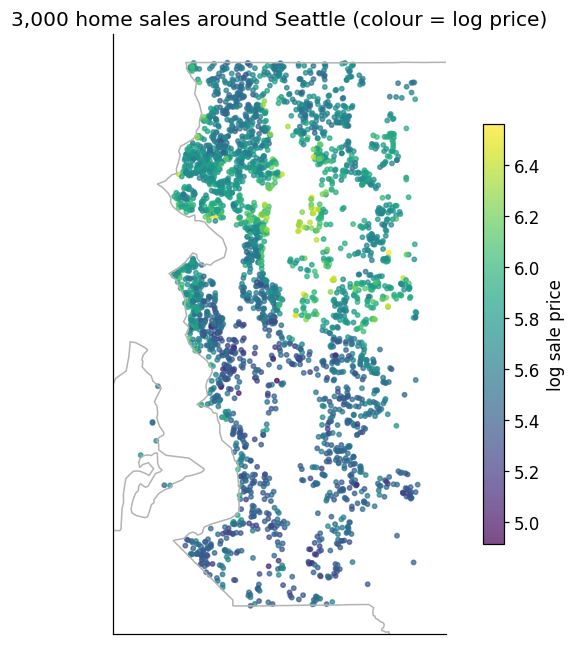

In [4]:
fig, ax = plt.subplots(figsize=(7, 6))
county.boundary.plot(ax=ax, color="0.7", linewidth=1)
sc = ax.scatter(coords[:, 0], coords[:, 1], c=y, cmap="viridis",
                s=8, alpha=0.7)
plt.colorbar(sc, ax=ax, shrink=0.7, label="log sale price")
ax.set_title("3,000 home sales around Seattle (colour = log price)")
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([]); zoom_to_data(ax)
plt.tight_layout(); plt.show()

## Part 1 — Spatial inductive bias

Every spatial model makes an assumption about geography — basically, *who
influences whom on the map*:

| Method | Spatial assumption |
|---|---|
| **Kriging** | a smooth, stationary covariance structure |
| **IDW** | closer points matter more (how much more is a free parameter) |
| **GWR** | the regression coefficients change smoothly across space |
| **Spatial CNN / GNN** | translation invariance, a fixed receptive field |

Each row is a **choice**. Different reasonable choices give different results,
but models almost never report this. In Part 1 we make that hidden uncertainty
visible.

### 1.1 A model with no geography

We start with a plain linear regression (OLS) that uses the house features but
**not the location**. If geography matters, the errors will not be random:
nearby houses will be wrong in the same direction. We check this with
**Moran's I**, which measures how clustered the errors are in space.

In [5]:
from sklearn.linear_model import LinearRegression
from libpysal.weights import KNN
from esda.moran import Moran

ols = LinearRegression().fit(X, y)
resid = y - ols.predict(X)
print(f"OLS R^2 (in-sample) = {ols.score(X, y):.3f}")

# Spatial weights: each house linked to its 8 nearest neighbours.
w = KNN.from_array(coords, k=8); w.transform = "r"
mi = Moran(resid, w, permutations=199)
print(f"Moran's I of OLS residuals = {mi.I:+.3f}  (p = {mi.p_sim:.3f})")
print("-> residuals are strongly clustered in space: geography is being ignored.")

OLS R^2 (in-sample) = 0.649
Moran's I of OLS residuals = +0.537  (p = 0.005)
-> residuals are strongly clustered in space: geography is being ignored.


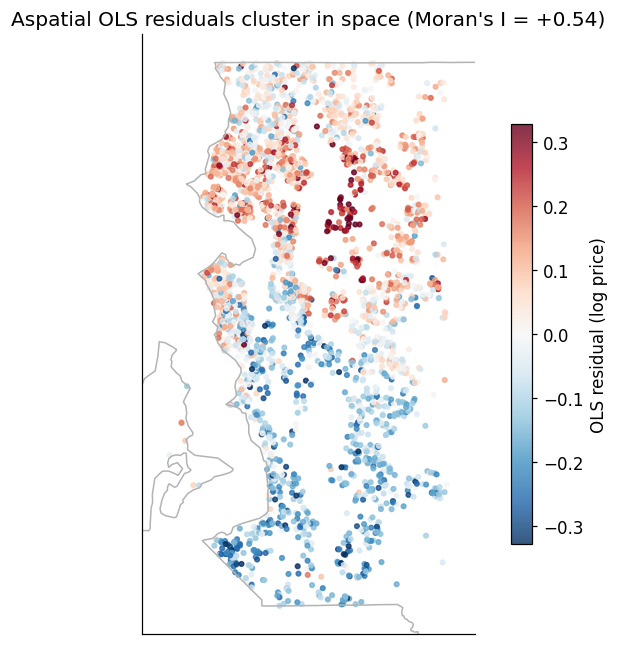

In [6]:
# Map the residuals: red = OLS under-predicts, blue = over-predicts.
vlim = np.percentile(np.abs(resid), 98)
fig, ax = plt.subplots(figsize=(7, 6))
county.boundary.plot(ax=ax, color="0.7", linewidth=1)
sc = ax.scatter(coords[:, 0], coords[:, 1], c=resid, cmap="RdBu_r",
                vmin=-vlim, vmax=vlim, s=9, alpha=0.8)
plt.colorbar(sc, ax=ax, shrink=0.7, label="OLS residual (log price)")
ax.set_title(f"Aspatial OLS residuals cluster in space (Moran's I = {mi.I:+.2f})")
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([]); zoom_to_data(ax)
plt.tight_layout(); plt.show()

The errors are not random noise — whole neighbourhoods are priced too high or
too low together. The data clearly needs geography. So let's add it. But *how*
we add it is a choice.

### 1.2 Same data, different assumption, different answer

The simplest spatial model is **inverse-distance weighting (IDW)**: predict each
location as a weighted average of nearby sales, with weight \(1/d^{\,p}\). The
power \(p\) is the assumption:

* \(p = 1\): far-away sales still count (a **long-range** assumption).
* \(p = 5\): only the closest sales count (a **local** assumption).

Both are reasonable. We build the price map with each, then map where they
**disagree**. That disagreement is real uncertainty — and standard tools never
show it.

In [7]:
def idw(train_xy, train_v, query_xy, power, eps=200.0):
    """Inverse-distance weighting. eps (metres) keeps weights finite."""
    dx = query_xy[:, None, 0] - train_xy[None, :, 0]
    dy = query_xy[:, None, 1] - train_xy[None, :, 1]
    d = np.sqrt(dx*dx + dy*dy) + eps
    wts = 1.0 / d**power
    return (wts * train_v[None, :]).sum(1) / wts.sum(1)

# Build a prediction grid clipped to King County.
from shapely.geometry import Point
minx, miny, maxx, maxy = coords[:, 0].min(), coords[:, 1].min(), coords[:, 0].max(), coords[:, 1].max()
gx = np.linspace(minx, maxx, 90); gy = np.linspace(miny, maxy, 90)
GX, GY = np.meshgrid(gx, gy)
grid_pts = gpd.GeoSeries([Point(x, y) for x, y in zip(GX.ravel(), GY.ravel())], crs=32610)
inside = grid_pts.within(county.union_all()).to_numpy().reshape(GX.shape)
qxy = np.column_stack([GX[inside], GY[inside]])

surf1 = np.full(GX.shape, np.nan); surf5 = np.full(GX.shape, np.nan)
surf1[inside] = idw(coords, y, qxy, power=1.0)
surf5[inside] = idw(coords, y, qxy, power=5.0)
disagree = np.abs(surf1 - surf5)
print(f"model-choice disagreement: mean = {np.nanmean(disagree):.3f}, "
      f"max = {np.nanmax(disagree):.3f} log-price units")

model-choice disagreement: mean = 0.139, max = 0.807 log-price units


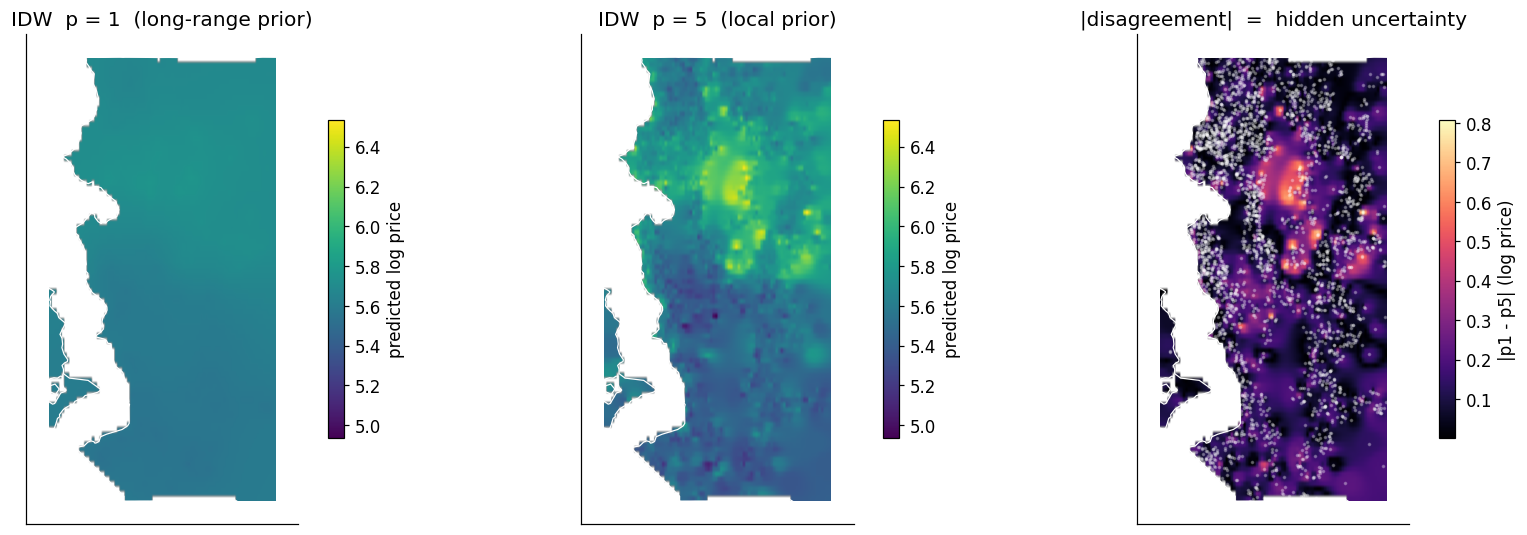

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
ext = [minx, maxx, miny, maxy]
vmin, vmax = np.nanmin([surf1, surf5]), np.nanmax([surf1, surf5])
for ax, surf, ttl in zip(axes[:2], [surf1, surf5],
                         ["IDW  p = 1  (long-range prior)", "IDW  p = 5  (local prior)"]):
    im = ax.imshow(surf, origin="lower", extent=ext, cmap="viridis",
                   vmin=vmin, vmax=vmax)
    county.boundary.plot(ax=ax, color="white", linewidth=0.8)
    ax.set_title(ttl); ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect("equal")
    zoom_to_data(ax)
    fig.colorbar(im, ax=ax, shrink=0.65, label="predicted log price")

im = axes[2].imshow(disagree, origin="lower", extent=ext, cmap="magma")
county.boundary.plot(ax=axes[2], color="white", linewidth=0.8)
axes[2].scatter(coords[:, 0], coords[:, 1], s=2, c="white", alpha=0.25)
axes[2].set_title("|disagreement|  =  hidden uncertainty")
axes[2].set_xticks([]); axes[2].set_yticks([]); axes[2].set_aspect("equal")
zoom_to_data(axes[2])
fig.colorbar(im, ax=axes[2], shrink=0.65, label="|p1 - p5| (log price)")
plt.tight_layout(); plt.show()

The two maps look similar, but they disagree the most **where sales are sparse**
(the white dots are the data). Where data is dense, the assumption barely
matters; where data is thin, it takes over. Same data, different assumption,
different answer.

### 1.3 GWR and its bandwidth

**Geographically Weighted Regression (GWR)** fits a separate regression at every
location, using nearby houses. This lets the effect of a feature change across
the city — for example, extra living area may add more value downtown than in the
suburbs. (This is called **spatial heterogeneity**.) The main choice is the
**bandwidth**: how many neighbours count as "local". We let `mgwr` pick it
automatically, then map the local effect of `sqft_living`.

In [9]:
from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW

# GWR needs locally non-constant predictors, so we drop the near-all-zero
# binary flags (waterfront, view) here and standardise the rest.
GWR_FEATS = ["sqft_living", "grade", "age", "condition", "bathrooms"]
Xg = df[GWR_FEATS].to_numpy(float)
Xs = (Xg - Xg.mean(0)) / Xg.std(0)
ys = (y - y.mean()).reshape(-1, 1)

# Data-driven adaptive bandwidth (number of neighbours). This search takes ~30 s.
bw = Sel_BW(coords, ys, Xs, fixed=False, kernel="bisquare").search(criterion="AICc")
gwr = GWR(coords, ys, Xs, bw, fixed=False, kernel="bisquare").fit()
print(f"selected adaptive bandwidth = {int(bw)} neighbours")
print(f"local R^2 ranges from {gwr.localR2.min():.2f} to {gwr.localR2.max():.2f}")

selected adaptive bandwidth = 112 neighbours


local R^2 ranges from 0.42 to 0.96


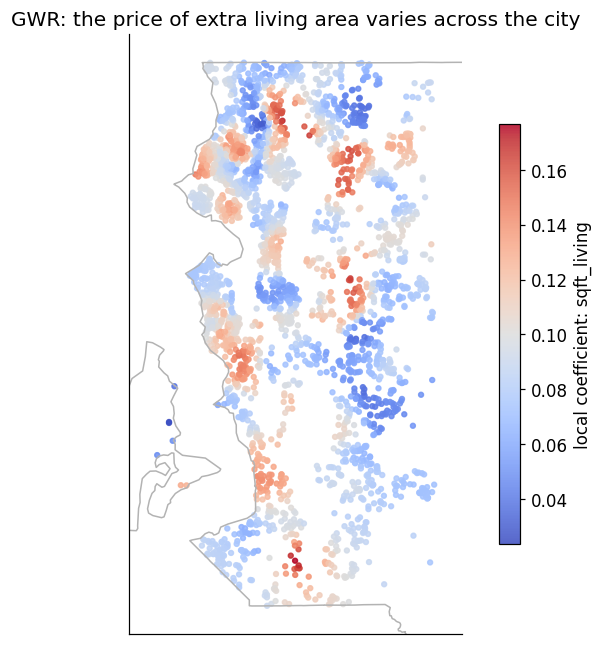

In [10]:
b_sqft = gwr.params[:, GWR_FEATS.index("sqft_living") + 1]   # +1 for intercept
fig, ax = plt.subplots(figsize=(7, 6))
county.boundary.plot(ax=ax, color="0.7", linewidth=1)
sc = ax.scatter(coords[:, 0], coords[:, 1], c=b_sqft, cmap="coolwarm",
                s=10, alpha=0.85)
plt.colorbar(sc, ax=ax, shrink=0.7, label="local coefficient: sqft_living")
ax.set_title("GWR: the price of extra living area varies across the city")
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([]); zoom_to_data(ax)
plt.tight_layout(); plt.show()

The effect is not the same everywhere — extra living area is worth more in some
neighbourhoods than others. But how *smooth* this map looks is set by the
bandwidth: a narrow bandwidth gives a bumpy map, a wide one flattens it out. The
bandwidth is another choice, and different choices tell different stories.

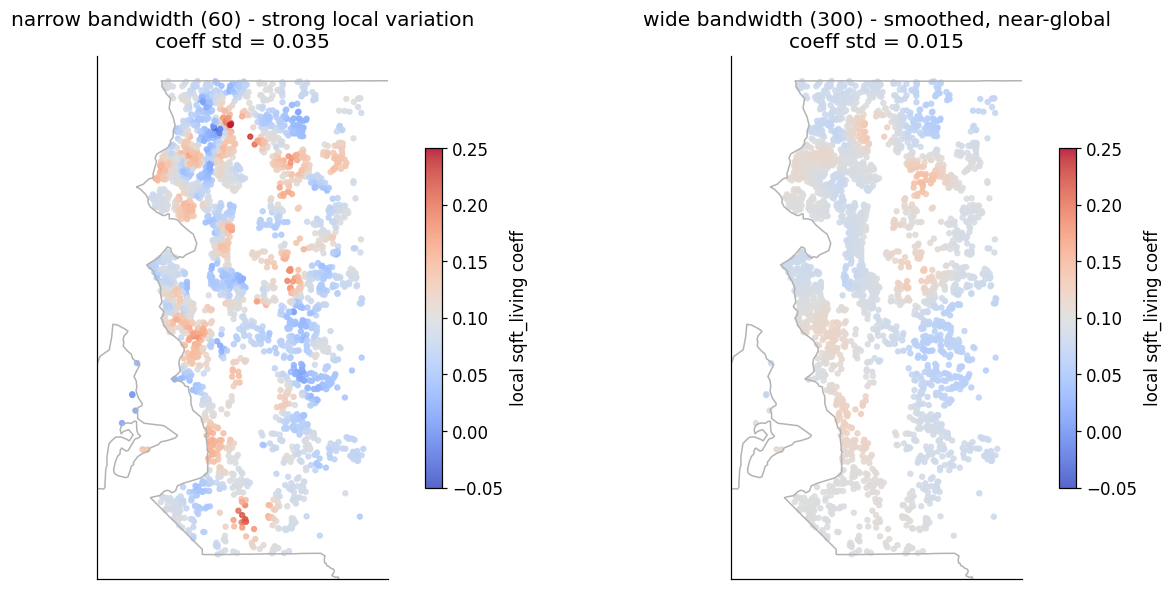

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, bwk, ttl in zip(axes, [60, 300],
                        ["narrow bandwidth (60) - strong local variation",
                         "wide bandwidth (300) - smoothed, near-global"]):
    g = GWR(coords, ys, Xs, bwk, fixed=False, kernel="bisquare").fit()
    bk = g.params[:, GWR_FEATS.index("sqft_living") + 1]
    county.boundary.plot(ax=ax, color="0.7", linewidth=1)
    sc = ax.scatter(coords[:, 0], coords[:, 1], c=bk, cmap="coolwarm",
                    s=10, alpha=0.85, vmin=-0.05, vmax=0.25)
    ax.set_title(f"{ttl}\ncoeff std = {bk.std():.3f}")
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([]); zoom_to_data(ax)
    fig.colorbar(sc, ax=ax, shrink=0.65, label="local sqft_living coeff")
plt.tight_layout(); plt.show()

### 1.4 Bootstrapping the spatial model

The maps above are single best guesses. How much would they change if we had
sampled slightly different houses? **Bootstrapping** answers this: we resample
the data many times, refit GWR each time, and predict everywhere. The spread of
these predictions is an uncertainty map.

In [12]:
B = 12                       # bootstrap replicates (small for speed)
bw_boot = 150                # fixed bandwidth so replicates are comparable
boot_pred = np.zeros((B, len(df)))
for b in range(B):
    idx = RNG.choice(len(df), len(df), replace=True)
    model_b = GWR(coords[idx], ys[idx], Xs[idx], bw_boot,
                  fixed=False, kernel="bisquare")
    boot_pred[b] = model_b.predict(coords, Xs).predictions.flatten()

boot_std = boot_pred.std(axis=0)
print(f"bootstrap prediction std: mean = {boot_std.mean():.3f}, "
      f"max = {boot_std.max():.3f} log-price units")

bootstrap prediction std: mean = 0.019, max = 0.147 log-price units


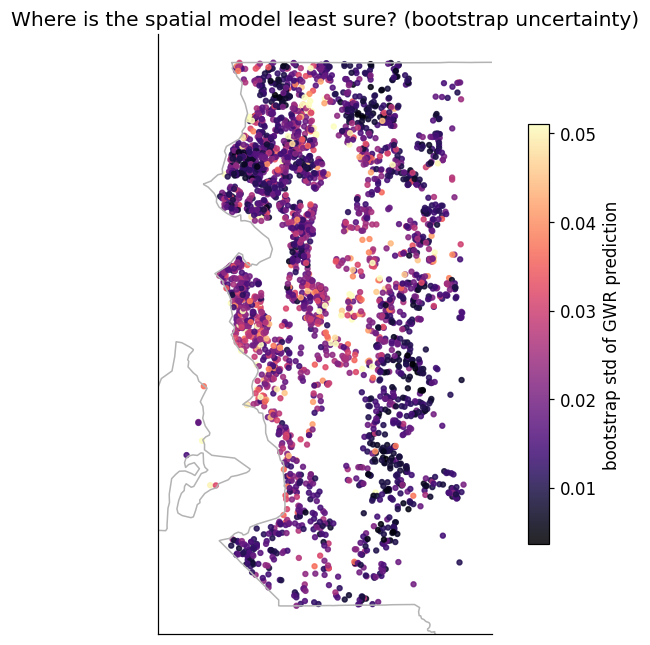

In [13]:
fig, ax = plt.subplots(figsize=(7, 6))
county.boundary.plot(ax=ax, color="0.7", linewidth=1)
sc = ax.scatter(coords[:, 0], coords[:, 1], c=boot_std, cmap="magma",
                s=10, alpha=0.85, vmax=np.percentile(boot_std, 98))
plt.colorbar(sc, ax=ax, shrink=0.7, label="bootstrap std of GWR prediction")
ax.set_title("Where is the spatial model least sure? (bootstrap uncertainty)")
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([]); zoom_to_data(ax)
plt.tight_layout(); plt.show()

Uncertainty is highest at the **edges** and in sparsely sampled areas — the same
places where the IDW assumption mattered most in 1.2. Two methods, one lesson: a
spatial model is least sure where it has the least data.

> ❓**Question:** Both the IDW disagreement (1.2) and the bootstrap spread (1.4)
> are large in sparse areas, but they measure different things. What does each one
> capture, and why is reporting only one of them not enough?

[Your Answer]

## Part 2 — Spatial transferability

We often train a model in one place and use it in another — a new city, a
neighbouring county, an unmapped area. Standard machine learning assumes the test
data looks like the training data. Geography breaks this: places differ, so a
model that ignores location is often **overconfident in a new region**.

To see this, we split King County in two: train on the **south**, then use the
model in the **north** without retraining.

### 2.1 Random split vs spatial split

A normal random train/test split hides the problem, because random test points
sit *among* the training points. A **spatial split** — train south, test north —
exposes it.

In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

north = coords[:, 1] >= np.median(coords[:, 1])   # northern half = transfer target
south = ~north                                     # southern half = training region

# (a) random split, same sample size as the spatial test set
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=north.mean(), random_state=0)
rf_rand = RandomForestRegressor(n_estimators=200, random_state=0, n_jobs=-1).fit(Xtr, ytr)
r2_rand = r2_score(yte, rf_rand.predict(Xte))

# (b) spatial split: train south, test north
rf_spat = RandomForestRegressor(n_estimators=200, random_state=0, n_jobs=-1).fit(X[south], y[south])
r2_spat = r2_score(y[north], rf_spat.predict(X[north]))
rmse_in  = mean_squared_error(y[south], rf_spat.predict(X[south])) ** 0.5
rmse_out = mean_squared_error(y[north], rf_spat.predict(X[north])) ** 0.5

print(f"Random split   R^2 = {r2_rand:.3f}   (looks great)")
print(f"Spatial split  R^2 = {r2_spat:.3f}   (the honest number)")
print(f"RMSE  in-region (south) = {rmse_in:.3f}   out-of-region (north) = {rmse_out:.3f}")

Random split   R^2 = 0.638   (looks great)
Spatial split  R^2 = 0.094   (the honest number)
RMSE  in-region (south) = 0.047   out-of-region (north) = 0.186


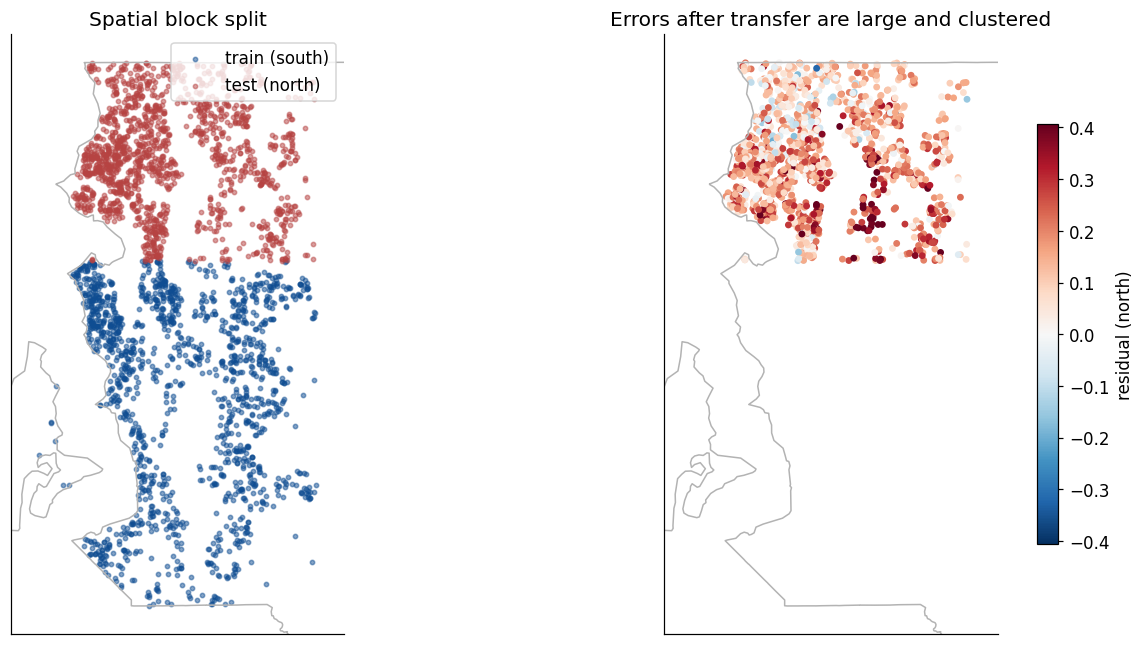

In [15]:
resid_n = y[north] - rf_spat.predict(X[north])
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
# left: the split
county.boundary.plot(ax=axes[0], color="0.7", linewidth=1)
axes[0].scatter(coords[south, 0], coords[south, 1], s=8, c="#0F4D92", alpha=0.5, label="train (south)")
axes[0].scatter(coords[north, 0], coords[north, 1], s=8, c="#B64342", alpha=0.5, label="test (north)")
axes[0].legend(loc="upper right"); axes[0].set_title("Spatial block split")
axes[0].set_aspect("equal"); axes[0].set_xticks([]); axes[0].set_yticks([]); zoom_to_data(axes[0])
# right: residuals in the transfer region
vlim = np.percentile(np.abs(resid_n), 98)
county.boundary.plot(ax=axes[1], color="0.7", linewidth=1)
sc = axes[1].scatter(coords[north, 0], coords[north, 1], c=resid_n, cmap="RdBu_r",
                     vmin=-vlim, vmax=vlim, s=12)
fig.colorbar(sc, ax=axes[1], shrink=0.7, label="residual (north)")
axes[1].set_title("Errors after transfer are large and clustered")
axes[1].set_aspect("equal"); axes[1].set_xticks([]); axes[1].set_yticks([]); zoom_to_data(axes[1])
plt.tight_layout(); plt.show()

The random split looks healthy, but the spatial split collapses: the same model
is much worse in the north, and its errors are clustered (it is biased, not just
noisy). This is **spatial domain shift**.

### 2.2 Bootstrapping does not see the shift

Would an ensemble warn us? We bootstrap the training data, refit, and look at the
spread of predictions — a common way to estimate uncertainty. Then we compare
that spread to the **true error** in each region.

In [16]:
Bs = 200
pred_n = np.zeros((Bs, north.sum()))
pred_s = np.zeros((Bs, south.sum()))
south_idx = np.where(south)[0]
for b in range(Bs):
    idx = RNG.choice(south_idx, len(south_idx), replace=True)
    mb = LinearRegression().fit(X[idx], y[idx])   # linear model, fast & analytic
    pred_n[b] = mb.predict(X[north])
    pred_s[b] = mb.predict(X[south])

base = LinearRegression().fit(X[south], y[south])
spread_s, spread_n = pred_s.std(0).mean(), pred_n.std(0).mean()
err_s = (mean_squared_error(y[south], base.predict(X[south]))) ** 0.5
err_n = (mean_squared_error(y[north], base.predict(X[north]))) ** 0.5
print(f"bootstrap spread:  south = {spread_s:.3f}   north = {spread_n:.3f}")
print(f"true RMSE:         south = {err_s:.3f}   north = {err_n:.3f}")
print(f"-> north error is {err_n/err_s:.1f}x the south error, but the bootstrap "
      f"spread barely moves ({spread_n/spread_s:.2f}x).")

bootstrap spread:  south = 0.009   north = 0.010
true RMSE:         south = 0.125   north = 0.183
-> north error is 1.5x the south error, but the bootstrap spread barely moves (1.08x).


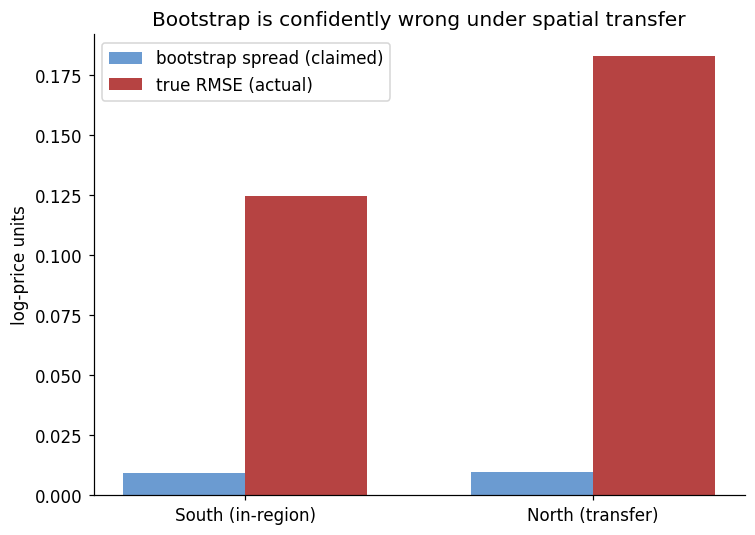

In [17]:
fig, ax = plt.subplots(figsize=(7, 5))
labels = ["South (in-region)", "North (transfer)"]
x = np.arange(2); wd = 0.35
ax.bar(x - wd/2, [spread_s, spread_n], wd, label="bootstrap spread (claimed)", color="#6b9bd1")
ax.bar(x + wd/2, [err_s, err_n], wd, label="true RMSE (actual)", color="#B64342")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("log-price units"); ax.legend()
ax.set_title("Bootstrap is confidently wrong under spatial transfer")
plt.tight_layout(); plt.show()

The bootstrap spread is tiny and **almost the same in both regions**, yet the
true error nearly doubles in the north. Bootstrapping only measures uncertainty
*within* the training distribution — it cannot tell that the new region is
different. Under spatial shift, it is **confidently wrong**.

### 2.3 GeoConformal Prediction

**Conformal Prediction (CP)** turns any model into prediction *intervals* with a
coverage guarantee — but only if the test data looks like the calibration data.
Under spatial transfer it doesn't, so standard CP covers less than it promises.
**GeoConformal Prediction (GeoCP)** fixes this by giving more weight to
calibration points near the test location, and by flagging points that are too
far from any data to certify.

> **What does "uncertifiable" mean?** When a test point has almost no calibration
> data near it, GeoCP cannot build a finite 90% interval — the honest answer is
> an *infinite* interval. GeoCP marks these points **uncertifiable**: rather than
> giving a falsely narrow interval, it says "I don't have enough nearby data to
> certify a prediction here."

We calibrate on the **south**, test on the **north**, and compare standard CP
with GeoCP from the `geocp` package.

In [18]:
from geocp import GeoConformalPrediction, GeoConformalRegressor
from geocp.weights import uniform_weights

# Split the southern (in-region) data into a model-fit set and a calibration set.
RNG.shuffle(south_idx)
half = len(south_idx) // 2
fit_idx, cal_idx = south_idx[:half], south_idx[half:]
model = RandomForestRegressor(n_estimators=200, random_state=0,
                              n_jobs=-1).fit(X[fit_idx], y[fit_idx])

ALPHA = 0.10   # target 90% coverage

# (a) standard split CP (uniform weights) -> assumes exchangeability
cp_std = GeoConformalPrediction(model.predict, X[cal_idx], y[cal_idx],
                                uniform_weights(), miscoverage_level=ALPHA)
res_std = cp_std.conformalize(X[north], y[north], coord_test=xy_km[north])

# (b) spatial GeoCP (Gaussian kernel on coordinates, bandwidth = 6 km)
geo = GeoConformalRegressor(model.predict, X[cal_idx], y[cal_idx], xy_km[cal_idx],
                            bandwidth=6.0, miscoverage_level=ALPHA)
res_geo = geo.geo_conformalize(X[north], y[north], xy_km[north])

print(f"target coverage = {1 - ALPHA:.0%}\n")
print(f"standard CP : coverage = {res_std.coverage:.3f}  mean width = {res_std.mean_width_finite:.3f}")
print(f"spatial GeoCP: coverage = {res_geo.coverage:.3f}  mean width = {res_geo.mean_width_finite:.3f}")
print(f"              {res_geo.frac_infinite:.0%} of the north flagged 'uncertifiable' "
      f"(too far from calibration data)")

target coverage = 90%

standard CP : coverage = 0.744  mean width = 0.448
spatial GeoCP: coverage = 0.907  mean width = 0.576
              47% of the north flagged 'uncertifiable' (too far from calibration data)


Standard CP promises 90% coverage but delivers less in the north, because the
southern errors are too optimistic. GeoCP restores coverage by widening intervals
where data is far away, and it is **honest about its limits**: instead of giving
a falsely narrow interval, it flags much of the north as *uncertifiable*.

The bandwidth is again a choice — it trades coverage against how much of the map
we are willing to certify:

In [19]:
print(f"{'bandwidth (km)':>14} | {'coverage':>9} | {'mean width':>10} | {'% uncertifiable':>15}")
print("-" * 58)
for bwk in [3.0, 6.0, 12.0, 24.0]:
    g = GeoConformalRegressor(model.predict, X[cal_idx], y[cal_idx], xy_km[cal_idx],
                              bandwidth=bwk, miscoverage_level=ALPHA)
    r = g.geo_conformalize(X[north], y[north], xy_km[north])
    print(f"{bwk:>14.0f} | {r.coverage:>9.3f} | {r.mean_width_finite:>10.3f} | {r.frac_infinite:>14.0%}")

bandwidth (km) |  coverage | mean width | % uncertifiable
----------------------------------------------------------


             3 |     0.994 |      0.616 |            90%


             6 |     0.907 |      0.576 |            47%


            12 |     0.809 |      0.502 |             0%


            24 |     0.773 |      0.465 |             0%


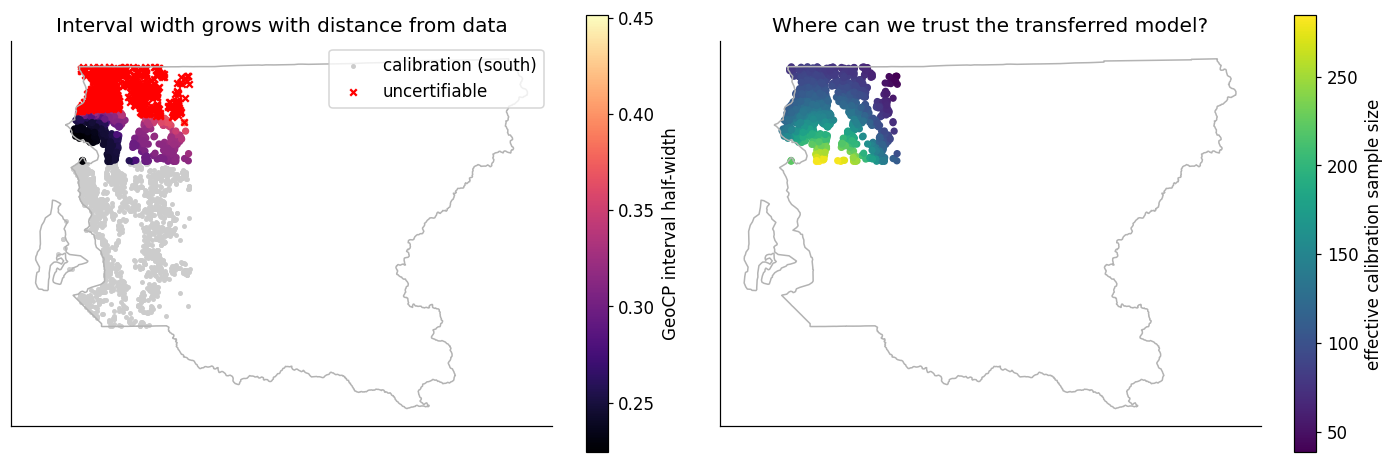

In [20]:
# Map the GeoCP interval width and the effective sample size (a 'trust' map).
res_b = geo.geo_conformalize(X[north], y[north], xy_km[north], bayesian=True, beta=0.9)
neff = res_b.n_eff
width = res_geo.uncertainty.copy()
finite = np.isfinite(width)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
county.boundary.plot(ax=axes[0], color="0.7", linewidth=1)
axes[0].scatter(coords[south, 0], coords[south, 1], s=5, c="0.8", label="calibration (south)")
sc0 = axes[0].scatter(coords[north][finite, 0], coords[north][finite, 1],
                      c=width[finite], cmap="magma", s=14)
axes[0].scatter(coords[north][~finite, 0], coords[north][~finite, 1],
                marker="x", c="red", s=18, label="uncertifiable")
fig.colorbar(sc0, ax=axes[0], shrink=0.7, label="GeoCP interval half-width")
axes[0].legend(loc="upper right"); axes[0].set_title("Interval width grows with distance from data")
axes[0].set_aspect("equal"); axes[0].set_xticks([]); axes[0].set_yticks([])

county.boundary.plot(ax=axes[1], color="0.7", linewidth=1)
sc1 = axes[1].scatter(coords[north, 0], coords[north, 1], c=neff, cmap="viridis", s=14)
fig.colorbar(sc1, ax=axes[1], shrink=0.7, label="effective calibration sample size")
axes[1].set_title("Where can we trust the transferred model?")
axes[1].set_aspect("equal"); axes[1].set_xticks([]); axes[1].set_yticks([])
plt.tight_layout(); plt.show()

Far from the data, the effective sample size drops and the intervals grow or
disappear. GeoCP puts "I don't know" on the map. That is the difference between a
model that is quietly overconfident and one that is **honest about where it can
be trusted**.

### 2.4 The same story at continental scale

Seattle south→north is a *gentle* transfer — the data is still only a few
kilometres away. What if we transfer across a whole continent, to a region with
**no nearby data at all**? We use a US climate dataset
(`US_Climate_ERA5_CLIMATE.csv`): a target `Y` and nine predictors at tens of
thousands of locations, each labelled with its US **climate region**. We train on
the **eastern** regions and predict the **western** ones.

In [21]:
clim = pd.read_csv("data/US_Climate_ERA5_CLIMATE.csv").sample(6000, random_state=7).reset_index(drop=True)
CF = [c for c in clim.columns if c.startswith("X")]
Xc = clim[CF].to_numpy(float)
yc = clim["Y"].to_numpy(float)
gc = gpd.GeoDataFrame(clim, geometry=gpd.points_from_xy(clim.lon, clim.lat),
                      crs=4326).to_crs(5070)            # US Albers equal-area
cxy_km = np.c_[gc.geometry.x.values, gc.geometry.y.values] / 1000.0

EAST = {"Northeast", "Southeast", "Ohio Valley", "South", "Upper Midwest"}
train_c = clim["region"].isin(EAST).to_numpy()          # SOURCE: eastern US
test_c = ~train_c                                        # TARGET: western US
print("train (East) n =", train_c.sum(), "| test (West) n =", test_c.sum())
print("target regions:", sorted(clim.loc[test_c, "region"].unique()))

train (East) n = 3149 | test (West) n = 2851
target regions: ['Northern Rockies & Plains', 'Northwest', 'Southwest', 'West']


In [22]:
# Fit on the East, measure error in-region vs after transfer.
rf_c = RandomForestRegressor(n_estimators=150, random_state=0, n_jobs=-1).fit(Xc[train_c], yc[train_c])
err_in  = mean_squared_error(yc[train_c], rf_c.predict(Xc[train_c])) ** 0.5
err_out = mean_squared_error(yc[test_c],  rf_c.predict(Xc[test_c]))  ** 0.5
print(f"in-region (East) R^2 = {r2_score(yc[train_c], rf_c.predict(Xc[train_c])):.3f}, RMSE = {err_in:.3f}")
print(f"transfer  (West) R^2 = {r2_score(yc[test_c],  rf_c.predict(Xc[test_c])):.3f}, RMSE = {err_out:.3f}")
print(f"-> error grows {err_out/err_in:.0f}x when the model leaves its training region.")

in-region (East) R^2 = 0.997, RMSE = 0.194
transfer  (West) R^2 = 0.631, RMSE = 2.913
-> error grows 15x when the model leaves its training region.


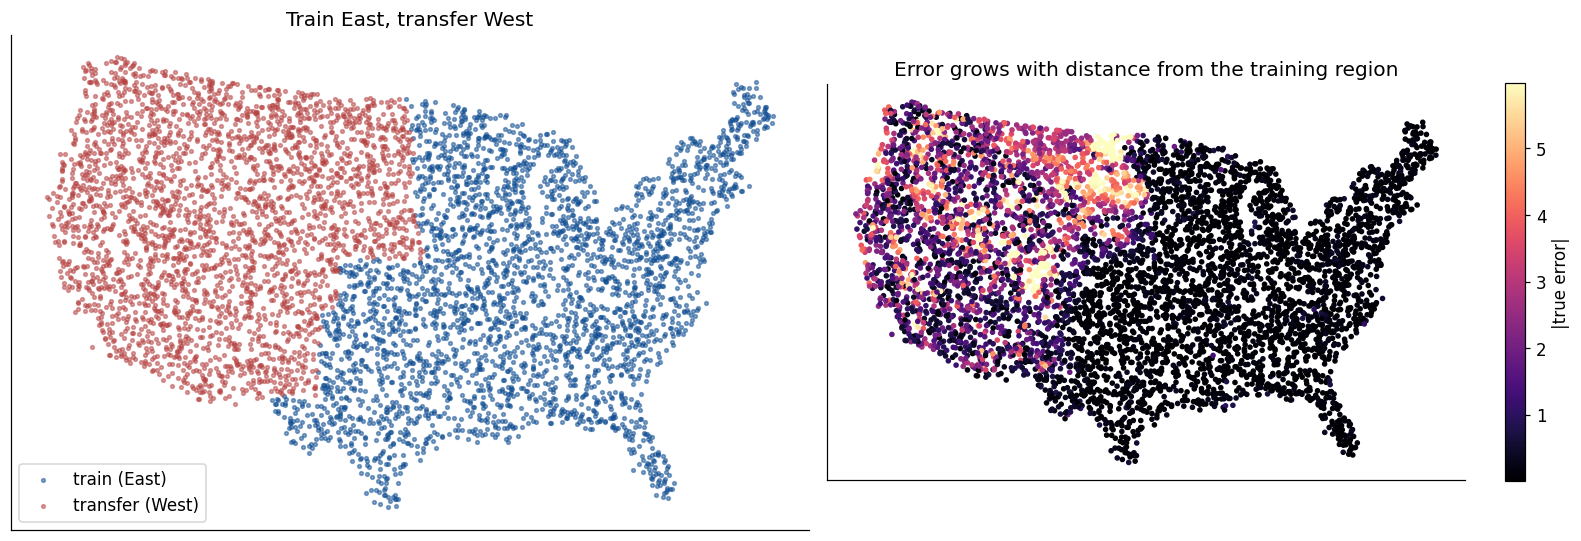

In [23]:
# Map: training region, and the true |error| across the whole country.
abs_err = np.abs(yc - rf_c.predict(Xc))
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
axes[0].scatter(cxy_km[train_c, 0], cxy_km[train_c, 1], s=6, c="#0F4D92", alpha=0.5, label="train (East)")
axes[0].scatter(cxy_km[test_c, 0],  cxy_km[test_c, 1],  s=6, c="#B64342", alpha=0.5, label="transfer (West)")
axes[0].legend(loc="lower left"); axes[0].set_title("Train East, transfer West")
sc = axes[1].scatter(cxy_km[:, 0], cxy_km[:, 1], c=abs_err, cmap="magma",
                     s=7, vmax=np.percentile(abs_err, 98))
fig.colorbar(sc, ax=axes[1], shrink=0.7, label="|true error|")
axes[1].set_title("Error grows with distance from the training region")
for ax in axes:
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

Now compare standard CP, bootstrapping, and GeoCP on this hard transfer. All the
calibration data is in the East.

In [24]:
tc = np.where(train_c)[0]; RNG.shuffle(tc)
hc = len(tc) // 2; fic, cic = tc[:hc], tc[hc:]
mc = RandomForestRegressor(n_estimators=150, random_state=0, n_jobs=-1).fit(Xc[fic], yc[fic])

# standard CP
cp_c = GeoConformalPrediction(mc.predict, Xc[cic], yc[cic], uniform_weights(), miscoverage_level=ALPHA)
rc_std = cp_c.conformalize(Xc[test_c], yc[test_c], coord_test=cxy_km[test_c])

# bootstrap overconfidence
Bc = 120; bp = np.zeros((Bc, test_c.sum()))
for b in range(Bc):
    idx = RNG.choice(tc, len(tc), replace=True)
    bp[b] = LinearRegression().fit(Xc[idx], yc[idx]).predict(Xc[test_c])
boot_spread_w = bp.std(0).mean()

# spatial GeoCP (bandwidth 300 km)
geo_c = GeoConformalRegressor(mc.predict, Xc[cic], yc[cic], cxy_km[cic], bandwidth=300.0, miscoverage_level=ALPHA)
rc_geo = geo_c.geo_conformalize(Xc[test_c], yc[test_c], cxy_km[test_c])

print(f"target coverage = {1 - ALPHA:.0%}  (West, no local calibration)\n")
print(f"standard CP : coverage = {rc_std.coverage:.3f}   <- promises 90%, delivers far less")
print(f"bootstrap   : spread = {boot_spread_w:.3f}  vs true RMSE = {err_out:.3f}  "
      f"({err_out/boot_spread_w:.0f}x too confident)")
print(f"spatial GeoCP: coverage = {rc_geo.coverage:.3f}, "
      f"{rc_geo.frac_infinite:.0%} of the West flagged uncertifiable")

target coverage = 90%  (West, no local calibration)

standard CP : coverage = 0.293   <- promises 90%, delivers far less
bootstrap   : spread = 0.175  vs true RMSE = 2.913  (17x too confident)
spatial GeoCP: coverage = 0.831, 70% of the West flagged uncertifiable


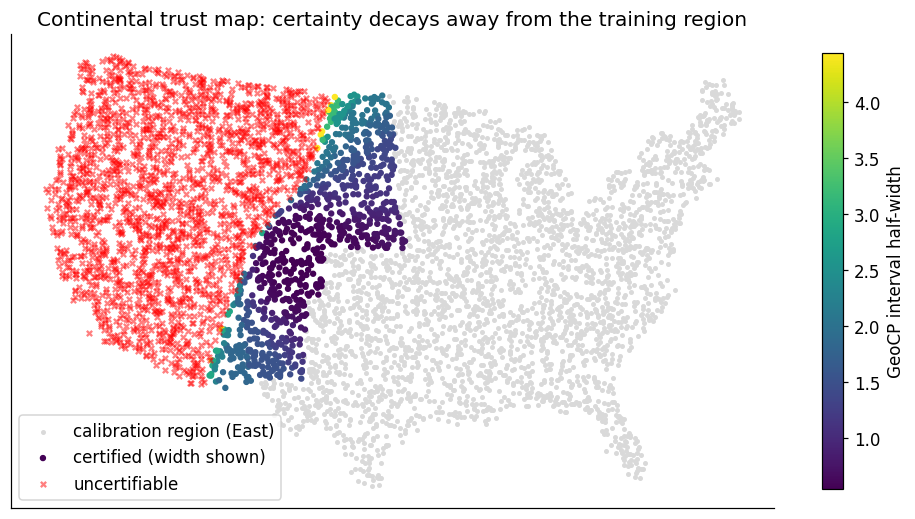

In [25]:
# The continental 'trust map': GeoCP interval width, with uncertifiable points marked.
u = rc_geo.uncertainty; fin = np.isfinite(u)
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(cxy_km[train_c, 0], cxy_km[train_c, 1], s=5, c="0.85", label="calibration region (East)")
sc = ax.scatter(cxy_km[test_c][fin, 0], cxy_km[test_c][fin, 1], c=u[fin],
                cmap="viridis", s=10, label="certified (width shown)")
ax.scatter(cxy_km[test_c][~fin, 0], cxy_km[test_c][~fin, 1], marker="x",
           c="red", s=12, alpha=0.5, label="uncertifiable")
fig.colorbar(sc, ax=ax, shrink=0.7, label="GeoCP interval half-width")
ax.legend(loc="lower left"); ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
ax.set_title("Continental trust map: certainty decays away from the training region")
plt.tight_layout(); plt.show()

At continental scale the lesson is sharper. Standard CP's 90% promise collapses,
and bootstrapping is now wrong by about 17×. GeoCP cannot *restore* coverage in
the far West — **no method can invent data where there is none** — but it is
honest: it widens intervals near the boundary and flags most of the West as
*uncertifiable*.

So spatial transfer is a spectrum:

* **Gentle transfer (Seattle, 2.3):** data is nearby → GeoCP *restores* coverage.
* **Extreme transfer (continental, 2.4):** no data in the target → GeoCP
  *refuses to certify* instead of being silently overconfident.

Either way, the fix is the same: **collect some data in the new region.**

> ❓**Question:** A colleague trained a model on your city and wants to use it in
> a neighbouring region, reporting bootstrap confidence intervals. Based on
> 2.2–2.4, what would you warn them about, and what would you suggest they report
> — or collect — instead?

[Your Answer]

## Wrap-up

Spatial modeling does not remove uncertainty — it moves it into the spatial
assumptions we make. No single number captures it, so different methods show
different things.

| Method | Uncertainty it reveals | What it misses |
|---|---|---|
| **Moran's I on residuals** | that geography is being ignored | the size of the resulting error |
| **IDW prior disagreement** | inductive-bias / model-choice uncertainty | data and transfer uncertainty |
| **GWR bandwidth contrast** | how the spatial prior shapes the answer | absolute correctness |
| **Bootstrapping** | data / parameter (epistemic) uncertainty | distribution shift — *confidently wrong under transfer* |
| **Spatial cross-validation** | the true error after transfer (city *and* continental scale) | per-location, calibrated intervals |
| **GeoConformal Prediction** | calibrated, location-aware intervals + an explicit "uncertifiable" flag | cannot invent coverage where no calibration data exists |

**Takeaways**

1. Every spatial assumption (IDW power, GWR bandwidth, kernel, receptive field)
   is a *choice*, and the choice is a hidden source of uncertainty.
2. Random splits hide spatial transfer error — always test with a **spatial**
   split.
3. Bootstrapping only sees uncertainty *within* the training distribution — it
   misses spatial shift and is overconfident in new regions.
4. **GeoConformal Prediction** gives location-aware intervals and, importantly,
   admits where it cannot certify a prediction at all.